In [1]:
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df = sns.load_dataset("titanic")

print("Titanic dataset loaded successfully.")

Titanic dataset loaded successfully.


In [5]:
df.to_csv(
    "C:\\Users\\user\\Desktop\\AI-ML Course\\zepto-ai-ml-capstone\\analytics\\titanic.csv",
    index=False
)

print("Raw Titanic dataset saved to analytics/titanic.csv")

Raw Titanic dataset saved to analytics/titanic.csv


In [6]:
print("Dataset shape:")
print(df.shape)

Dataset shape:
(891, 15)


In [7]:
print("Dataset information:")
df.info()

Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


In [8]:
print("Dataset information:")
df.info()

Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


In [9]:
missing_percentage = (
    df.isnull()
    .mean()
    .mul(100)
)

missing_percentage = (
    missing_percentage[
        missing_percentage > 0
    ]
    .sort_values(
        ascending=False
    )
)

print("Missing-value percentages:")

print(
    missing_percentage
)

Missing-value percentages:
deck           77.216611
age            19.865320
embarked        0.224467
embark_town     0.224467
dtype: float64


In [10]:
missing_table = pd.DataFrame({
    "missing_count": df.isnull().sum(),
    "missing_percentage": (
        df.isnull().mean() * 100
    )
})

missing_table = (
    missing_table[
        missing_table["missing_count"] > 0
    ]
    .sort_values(
        "missing_percentage",
        ascending=False
    )
)

print(missing_table)

             missing_count  missing_percentage
deck                   688           77.216611
age                    177           19.865320
embarked                 2            0.224467
embark_town              2            0.224467


In [11]:
print("\nFirst 5 rows:")
display(df.head())


First 5 rows:


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [12]:
print("\nColumns:")
print(df.columns.tolist())


Columns:
['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']


In [13]:
missing_table = pd.DataFrame({
    "missing_count": df.isnull().sum(),
    "missing_percentage": (
        df.isnull().mean() * 100
    )
})

missing_table = (
    missing_table[
        missing_table["missing_count"] > 0
    ]
    .sort_values(
        "missing_percentage",
        ascending=False
    )
)

print("Missing-value summary:")
print(missing_table)

Missing-value summary:
             missing_count  missing_percentage
deck                   688           77.216611
age                    177           19.865320
embarked                 2            0.224467
embark_town              2            0.224467


In [14]:
for column, row in missing_table.iterrows():

    print(
        f"{column}: "
        f"{int(row['missing_count'])} missing values "
        f"({row['missing_percentage']:.2f}%)"
    )

deck: 688 missing values (77.22%)
age: 177 missing values (19.87%)
embarked: 2 missing values (0.22%)
embark_town: 2 missing values (0.22%)


In [15]:
df = df.drop(
    columns=["deck"]
)

print("Dropped 'deck' because of very high missingness.")

Dropped 'deck' because of very high missingness.


In [16]:
age_median = df["age"].median()

df["age"] = df["age"].fillna(
    age_median
)

print(
    "Missing age values replaced with median:",
    age_median
)

Missing age values replaced with median: 28.0


In [17]:
rows_before = len(df)

df = df.dropna(
    subset=["embarked"]
)

rows_after = len(df)

print(
    "Rows dropped due to missing embarked:",
    rows_before - rows_after
)

Rows dropped due to missing embarked: 2


In [18]:
df = df.drop(
    columns=["embark_town"]
)

In [19]:
missing_after = pd.DataFrame({
    "missing_count": df.isnull().sum(),
    "missing_percentage": (
        df.isnull().mean() * 100
    )
})

missing_after = missing_after[
    missing_after["missing_count"] > 0
]

print("Missing values after cleaning:")
print(missing_after)

Missing values after cleaning:
Empty DataFrame
Columns: [missing_count, missing_percentage]
Index: []


In [20]:
print("Shape after cleaning:")
print(df.shape)

Shape after cleaning:
(889, 13)


In [21]:
df.to_csv(
    "titanic_cleaned.csv",
    index=False
)

print(
    "Cleaned Titanic dataset saved as titanic_cleaned.csv"
)

Cleaned Titanic dataset saved as titanic_cleaned.csv


In [22]:
print(df.shape)
print(df.isnull().sum())

(889, 13)
survived      0
pclass        0
sex           0
age           0
sibsp         0
parch         0
fare          0
embarked      0
class         0
who           0
adult_male    0
alive         0
alone         0
dtype: int64


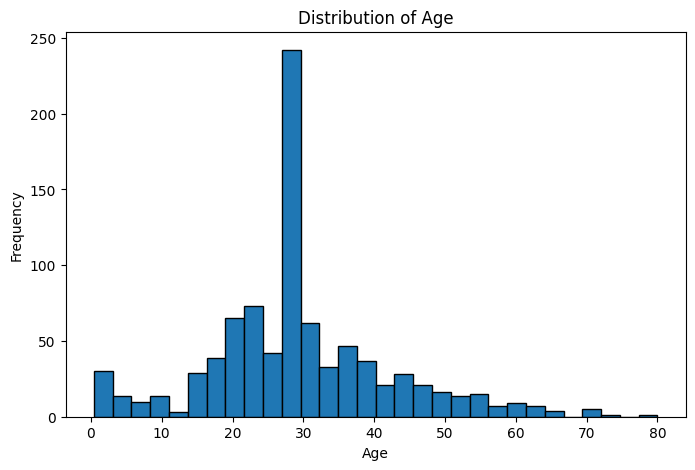

In [32]:

plt.figure(figsize=(8, 5))

plt.hist(
    df["age"],
    bins=30,
    edgecolor="black"
)

plt.title("Distribution of Age")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.savefig(
    "outputs/charts/age_histogram.png",
    bbox_inches="tight"
)

plt.show()

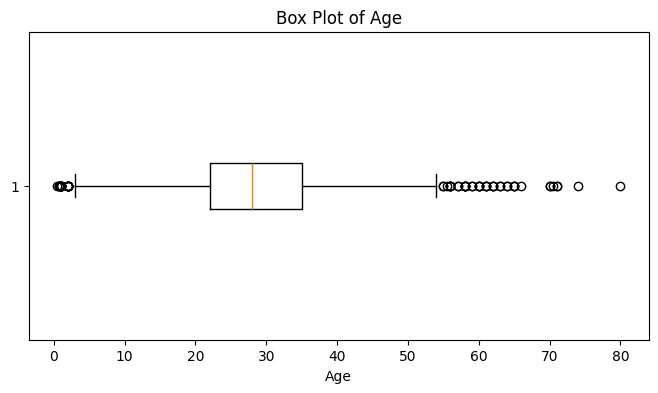

In [37]:
plt.figure(figsize=(8, 4))

plt.boxplot(
    df["age"],
    vert=False
)

plt.title("Box Plot of Age")
plt.xlabel("Age")

plt.savefig(
    "outputs/charts/age_boxplot.png",
    bbox_inches="tight"
)

plt.show()

In [25]:
Q1_age = df["age"].quantile(0.25)
Q3_age = df["age"].quantile(0.75)

IQR_age = Q3_age - Q1_age

lower_age = Q1_age - 1.5 * IQR_age
upper_age = Q3_age + 1.5 * IQR_age

age_outliers = df[
    (df["age"] < lower_age) |
    (df["age"] > upper_age)
]

print("Age Q1:", Q1_age)
print("Age Q3:", Q3_age)
print("Age IQR:", IQR_age)

print("Age lower bound:", lower_age)
print("Age upper bound:", upper_age)

print(
    "Number of age outliers:",
    len(age_outliers)
)

Age Q1: 22.0
Age Q3: 35.0
Age IQR: 13.0
Age lower bound: 2.5
Age upper bound: 54.5
Number of age outliers: 65


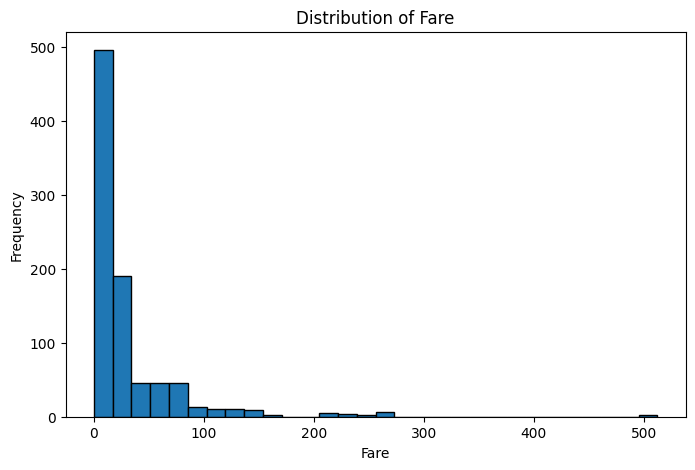

In [38]:
plt.figure(figsize=(8, 5))

plt.hist(
    df["fare"],
    bins=30,
    edgecolor="black"
)

plt.title("Distribution of Fare")
plt.xlabel("Fare")
plt.ylabel("Frequency")

plt.savefig(
    "outputs/charts/fare_histogram.png",
    bbox_inches="tight"
)

plt.show()

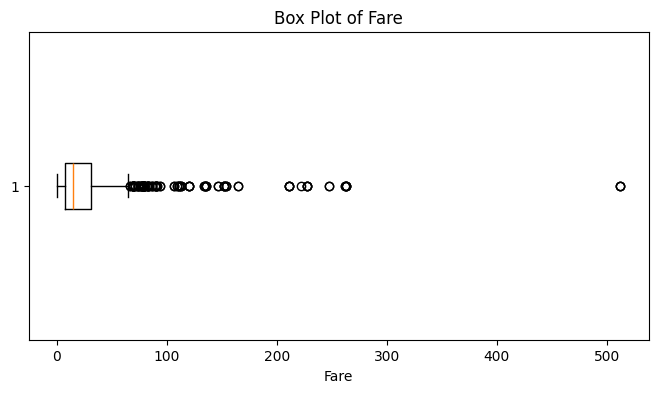

In [39]:
plt.figure(figsize=(8, 4))

plt.boxplot(
    df["fare"],
    vert=False
)

plt.title("Box Plot of Fare")
plt.xlabel("Fare")

plt.savefig(
    "outputs/charts/fare_boxplot.png",
    bbox_inches="tight"
)

plt.show()

In [28]:
Q1_fare = df["fare"].quantile(0.25)
Q3_fare = df["fare"].quantile(0.75)

IQR_fare = Q3_fare - Q1_fare

lower_fare = Q1_fare - 1.5 * IQR_fare
upper_fare = Q3_fare + 1.5 * IQR_fare

fare_outliers = df[
    (df["fare"] < lower_fare) |
    (df["fare"] > upper_fare)
]

print("Fare Q1:", Q1_fare)
print("Fare Q3:", Q3_fare)
print("Fare IQR:", IQR_fare)

print("Fare lower bound:", lower_fare)
print("Fare upper bound:", upper_fare)

print(
    "Number of fare outliers:",
    len(fare_outliers)
)

Fare Q1: 7.8958
Fare Q3: 31.0
Fare IQR: 23.1042
Fare lower bound: -26.7605
Fare upper bound: 65.6563
Number of fare outliers: 114


In [29]:
fare_mean = df["fare"].mean()

fare_median = df["fare"].median()

fare_mode = df["fare"].mode()

print("Fare mean:", fare_mean)
print("Fare median:", fare_median)
print("Fare mode:", fare_mode.tolist())

Fare mean: 32.09668087739032
Fare median: 14.4542
Fare mode: [8.05]


In [30]:
fare_skewness = df["fare"].skew()

print(
    "Fare skewness:",
    fare_skewness
)

Fare skewness: 4.801440211044194


In [40]:
survival_by_sex = (
    df.groupby("sex")["survived"]
    .mean()
    .mul(100)
    .round(2)
)

print("Survival rate by sex (%):")
print(survival_by_sex)

Survival rate by sex (%):
sex
female    74.04
male      18.89
Name: survived, dtype: float64


In [41]:
survival_by_class = (
    df.groupby("pclass")["survived"]
    .mean()
    .mul(100)
    .round(2)
)

print("Survival rate by passenger class (%):")
print(survival_by_class)

Survival rate by passenger class (%):
pclass
1    62.62
2    47.28
3    24.24
Name: survived, dtype: float64


In [42]:
survival_by_sex_class = (
    df.groupby(
        ["sex", "pclass"]
    )["survived"]
    .mean()
    .mul(100)
    .round(2)
)

print(
    "Survival rate by sex and passenger class (%):"
)

print(survival_by_sex_class)

Survival rate by sex and passenger class (%):
sex     pclass
female  1         96.74
        2         92.11
        3         50.00
male    1         36.89
        2         15.74
        3         13.54
Name: survived, dtype: float64


In [43]:
survival_table = (
    df.groupby(
        ["sex", "pclass"]
    )["survived"]
    .mean()
    .mul(100)
    .round(2)
    .reset_index()
)

survival_table.columns = [
    "sex",
    "pclass",
    "survival_rate"
]

print(survival_table)

      sex  pclass  survival_rate
0  female       1          96.74
1  female       2          92.11
2  female       3          50.00
3    male       1          36.89
4    male       2          15.74
5    male       3          13.54


In [60]:
survival_table.to_csv(
    "C:\\Users\\user\\Desktop\\AI-ML Course\\zepto-ai-ml-capstone\\analytics\\outputs\\charts\\tables\\survival_by_sex_class.csv",
    index=False
)

In [44]:
correlation_columns = [
    "survived",
    "pclass",
    "age",
    "sibsp",
    "parch",
    "fare"
]

correlation_matrix = df[
    correlation_columns
].corr()

print("Correlation matrix:")
print(correlation_matrix)

Correlation matrix:
          survived    pclass       age     sibsp     parch      fare
survived  1.000000 -0.335549 -0.069822 -0.034040  0.083151  0.255290
pclass   -0.335549  1.000000 -0.336512  0.081656  0.016824 -0.548193
age      -0.069822 -0.336512  1.000000 -0.232543 -0.171485  0.093707
sibsp    -0.034040  0.081656 -0.232543  1.000000  0.414542  0.160887
parch     0.083151  0.016824 -0.171485  0.414542  1.000000  0.217532
fare      0.255290 -0.548193  0.093707  0.160887  0.217532  1.000000


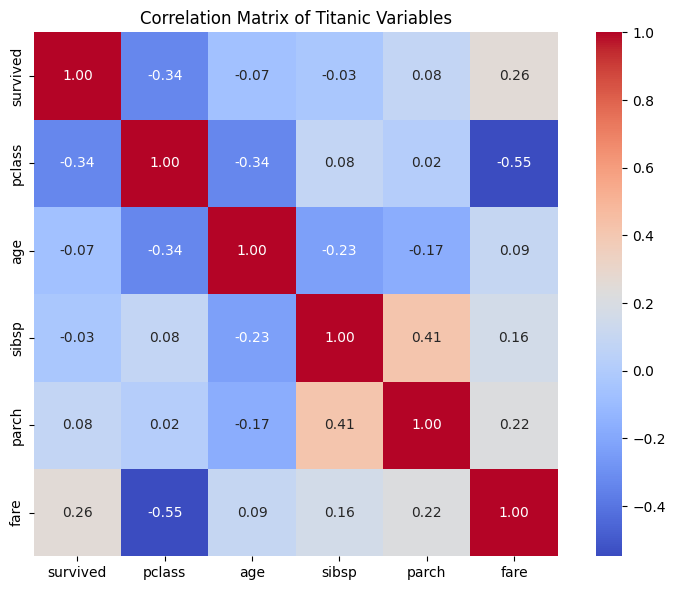

In [45]:
plt.figure(
    figsize=(8, 6)
)

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    square=True
)

plt.title(
    "Correlation Matrix of Titanic Variables"
)

plt.tight_layout()

plt.savefig(
    "outputs/charts/correlation_heatmap.png",
    bbox_inches="tight"
)

plt.show()

In [46]:
corr_pairs = (
    correlation_matrix
    .where(
        ~pd.DataFrame(
            True,
            index=correlation_matrix.index,
            columns=correlation_matrix.columns
        ).values
    )
)

In [47]:
import numpy as np

In [48]:
corr_pairs = correlation_matrix.where(
    ~np.eye(
        correlation_matrix.shape[0],
        dtype=bool
    )
)

strongest_pair = (
    corr_pairs.abs()
    .stack()
    .sort_values(
        ascending=False
    )
)

print("Strongest correlation pairs:")
print(
    strongest_pair.head(10)
)

Strongest correlation pairs:
pclass    fare        0.548193
fare      pclass      0.548193
sibsp     parch       0.414542
parch     sibsp       0.414542
age       pclass      0.336512
pclass    age         0.336512
          survived    0.335549
survived  pclass      0.335549
fare      survived    0.255290
survived  fare        0.255290
dtype: float64


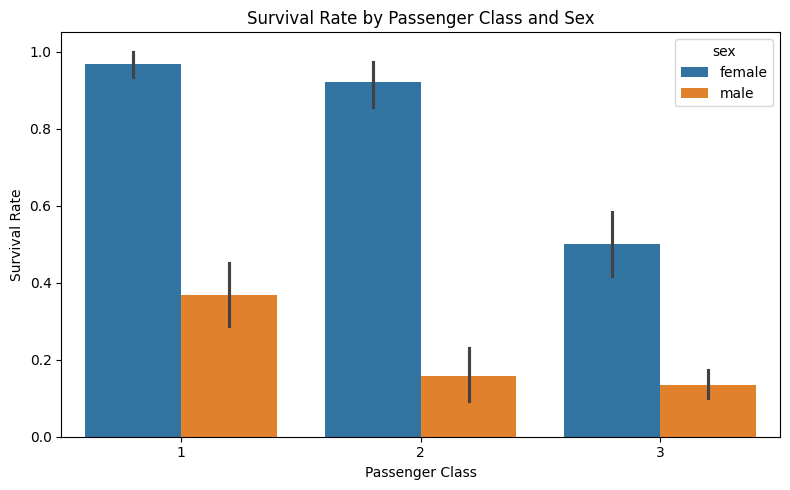

In [49]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x="pclass",
    y="survived",
    hue="sex"
)

plt.title(
    "Survival Rate by Passenger Class and Sex"
)

plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")

plt.tight_layout()

plt.savefig(
    "outputs/charts/survival_sex_class.png",
    bbox_inches="tight"
)

plt.show()

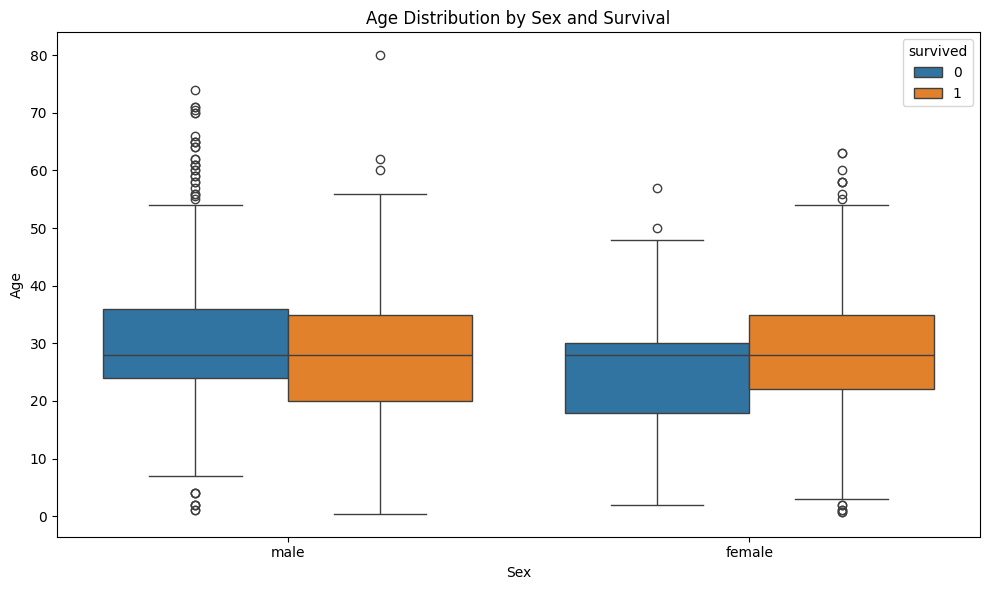

In [50]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="sex",
    y="age",
    hue="survived"
)

plt.title(
    "Age Distribution by Sex and Survival"
)

plt.xlabel("Sex")
plt.ylabel("Age")

plt.tight_layout()

plt.savefig(
    "outputs/charts/age_sex_survival.png",
    bbox_inches="tight"
)

plt.show()

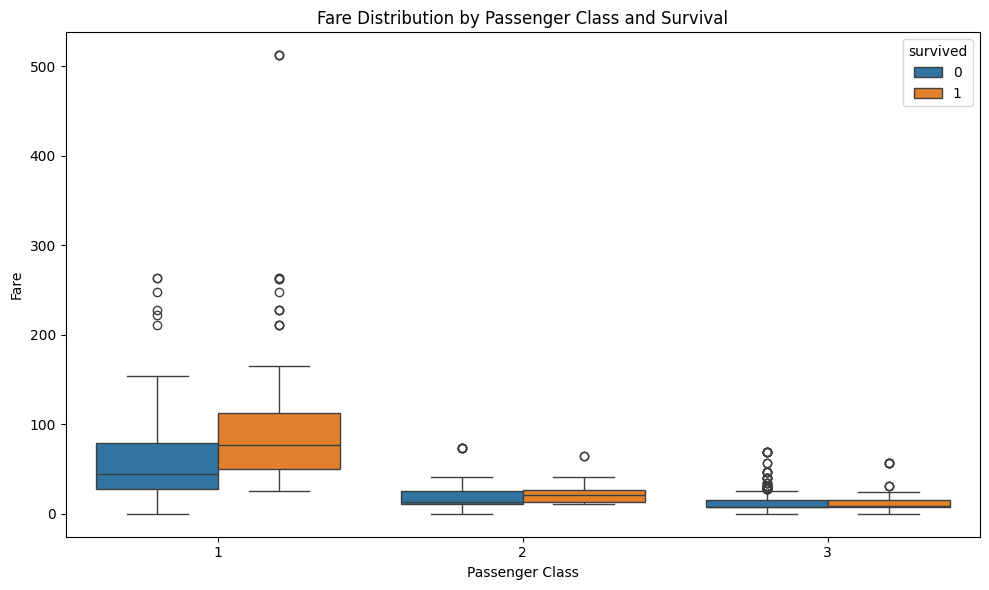

In [51]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="pclass",
    y="fare",
    hue="survived"
)

plt.title(
    "Fare Distribution by Passenger Class and Survival"
)

plt.xlabel("Passenger Class")
plt.ylabel("Fare")

plt.tight_layout()

plt.savefig(
    "outputs/charts/fare_class_survival.png",
    bbox_inches="tight"
)

plt.show()

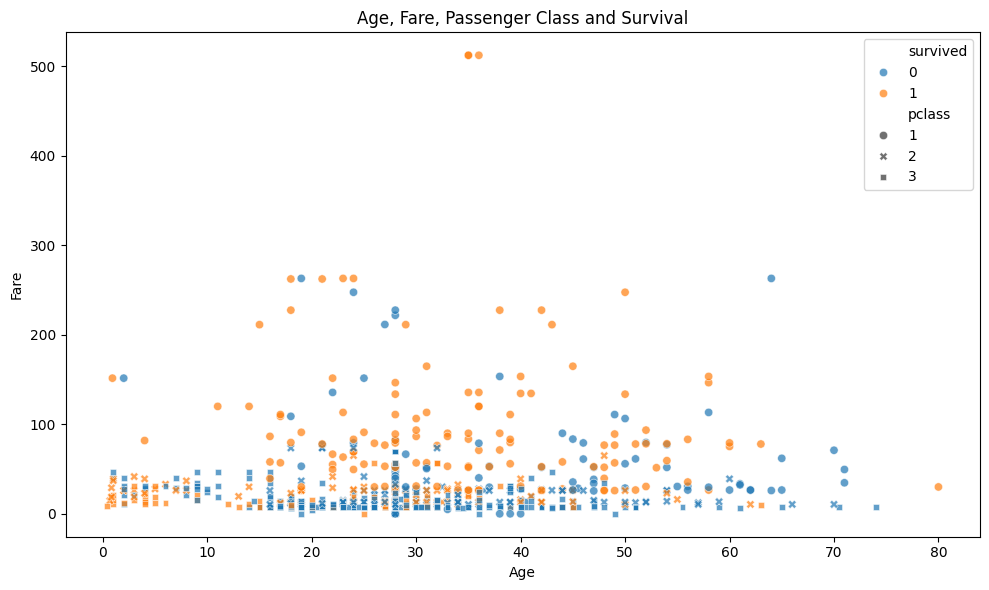

In [52]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="age",
    y="fare",
    hue="survived",
    style="pclass",
    alpha=0.7
)

plt.title(
    "Age, Fare, Passenger Class and Survival"
)

plt.xlabel("Age")
plt.ylabel("Fare")

plt.tight_layout()

plt.savefig(
    "outputs/charts/age_fare_class_survival.png",
    bbox_inches="tight"
)

plt.show()

### Multivariate Analysis Observations

1. Survival varied substantially by both passenger class and sex.
   Female passengers generally showed higher survival rates than male
   passengers across passenger classes.

2. Age distributions differed between survivors and non-survivors,
   with survival patterns also varying by sex.

3. Fare was strongly associated with passenger class, with higher
   classes generally having higher fares. Survival also varied across
   these groups.

4. The age-fare scatter plot shows that passenger class and fare are
   related, while survival outcomes are distributed differently across
   age and fare ranges.

In [53]:

# --------------------------------
# Standardization demonstration
# --------------------------------

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_values = scaler.fit_transform(
    df[["age", "fare"]]
)

scaled_df = pd.DataFrame(
    scaled_values,
    columns=["age_scaled", "fare_scaled"]
)

print("Standardized data:")
print(scaled_df.head())


Standardized data:
   age_scaled  fare_scaled
0   -0.563674    -0.500240
1    0.669217     0.788947
2   -0.255451    -0.486650
3    0.438050     0.422861
4    0.438050    -0.484133


In [54]:
print("\nStandardized means:")
print(scaled_df.mean())

print("\nStandardized standard deviations:")
print(scaled_df.std())


Standardized means:
age_scaled     2.717486e-16
fare_scaled    1.398706e-16
dtype: float64

Standardized standard deviations:
age_scaled     1.000563
fare_scaled    1.000563
dtype: float64


In [55]:
print(
    scaled_df.std(ddof=0)
)

age_scaled     1.0
fare_scaled    1.0
dtype: float64


In [56]:
# --------------------------------
# Final cleaned dataset summary
# --------------------------------

print("Final dataset shape:")
print(df.shape)

print("\nFinal columns:")
print(df.columns.tolist())

print("\nFinal data types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

Final dataset shape:
(889, 13)

Final columns:
['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'alive', 'alone']

Final data types:
survived         int64
pclass           int64
sex                str
age            float64
sibsp            int64
parch            int64
fare           float64
embarked           str
class         category
who                str
adult_male        bool
alive              str
alone             bool
dtype: object

Missing values:
survived      0
pclass        0
sex           0
age           0
sibsp         0
parch         0
fare          0
embarked      0
class         0
who           0
adult_male    0
alive         0
alone         0
dtype: int64


In [57]:
# --------------------------------
# Final cleaned dataset summary
# --------------------------------

print("Final dataset shape:")
print(df.shape)

print("\nFinal columns:")
print(df.columns.tolist())

print("\nFinal data types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

Final dataset shape:
(889, 13)

Final columns:
['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'alive', 'alone']

Final data types:
survived         int64
pclass           int64
sex                str
age            float64
sibsp            int64
parch            int64
fare           float64
embarked           str
class         category
who                str
adult_male        bool
alive              str
alone             bool
dtype: object

Missing values:
survived      0
pclass        0
sex           0
age           0
sibsp         0
parch         0
fare          0
embarked      0
class         0
who           0
adult_male    0
alive         0
alone         0
dtype: int64


In [61]:
correlation_matrix.to_csv(
    "C:\\Users\\user\\Desktop\\AI-ML Course\\zepto-ai-ml-capstone\\analytics\\outputs\\charts\\tables\\correlation_matrix.csv",
    index=False
)

In [ ]:
# --------------------------------
# Save EDA summary
# --------------------------------

with open(
    "outputs/eda_summary.txt",
    "w",
    encoding="utf-8"
) as file:

    file.write("TITANIC DATASET - EDA SUMMARY\n")
    file.write("=" * 40 + "\n\n")

    file.write(
        f"Final dataset shape: {df.shape}\n\n"
    )

    file.write(
        "Age statistics:\n"
    )

    file.write(
        f"Q1: {Q1_age:.2f}\n"
    )

    file.write(
        f"Q3: {Q3_age:.2f}\n"
    )

    file.write(
        f"IQR: {IQR_age:.2f}\n"
    )

    file.write(
        f"Age outliers: {len(age_outliers)}\n\n"
    )

    file.write(
        "Fare statistics:\n"
    )

    file.write(
        f"Mean: {fare_mean:.2f}\n"
    )

    file.write(
        f"Median: {fare_median:.2f}\n"
    )

    file.write(
        f"Mode: {fare_mode.tolist()}\n"
    )

    file.write(
        f"Fare Q1: {Q1_fare:.2f}\n"
    )

    file.write(
        f"Fare Q3: {Q3_fare:.2f}\n"
    )

    file.write(
        f"Fare IQR: {IQR_fare:.2f}\n"
    )

    file.write(
        f"Fare outliers: {len(fare_outliers)}\n"
    )

    file.write(
        f"Fare skewness: {fare_skewness:.4f}\n\n"
    )

    file.write(
        "Survival by sex:\n"
    )

    file.write(
        survival_by_sex.to_string()
    )

    file.write("\n\n") 
    

    file.write(
        "Survival by passenger class:\n"
    )

    file.write(
        survival_by_class.to_string()
    )

print(
    "EDA summary saved successfully."
)

EDA summary saved successfully.
